#Step 1 - Setup and scope

In [ ]:
from google.colab import drive
from pathlib import Path
import pandas as pd
import zipfile

drive.mount('/content/drive')

DRIVE     = Path('/content/drive/MyDrive/m5_project')
LOCAL     = Path('/content/m5')
PROCESSED = DRIVE / 'processed'
PROCESSED.mkdir(parents=True, exist_ok=True)
LOCAL.mkdir(parents=True, exist_ok=True)

STORES  = ['CA_1', 'CA_2']
N_DAYS  = 1095
END_D   = 1941
START_D = END_D - N_DAYS + 1
HORIZON = 28

TEST_START = END_D - HORIZON + 1      # 1914
VAL_START  = TEST_START - HORIZON     # 1886

ID_COLS = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
D_COLS  = [f'd_{i}' for i in range(START_D, END_D + 1)]

print(f'stores {STORES}   days d_{START_D}..d_{END_D}')
print(f'train  d_{START_D} .. d_{VAL_START-1}')
print(f'val    d_{VAL_START} .. d_{TEST_START-1}')
print(f'test   d_{TEST_START} .. d_{END_D}   <- untouched until Phase 10')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
stores ['CA_1', 'CA_2']   days d_847..d_1941
train  d_847 .. d_1885
val    d_1886 .. d_1913
test   d_1914 .. d_1941   <- untouched until Phase 10


#Step 2 - Extract raw CSVs (skips if already there)

In [ ]:
if not (LOCAL / 'sales_train_evaluation.csv').exists():
    with zipfile.ZipFile(DRIVE / 'raw' / 'm5-forecasting-accuracy.zip') as z:
        z.extractall(LOCAL)
    print('extracted')
else:
    print('CSVs already present')

print(sorted(p.name for p in LOCAL.glob('*.csv')))

CSVs already present
['calendar.csv', 'sales_train_evaluation.csv', 'sales_train_validation.csv', 'sample_submission.csv', 'sell_prices.csv']


# Step 3 - Load wide, filter to scope
- Load only the columns and stores in scope, then record total units and expected row count

In [ ]:
wide = pd.read_csv(LOCAL / 'sales_train_evaluation.csv', usecols=ID_COLS + D_COLS)
wide = wide[wide.store_id.isin(STORES)].reset_index(drop=True)

WIDE_TOTAL_UNITS = int(wide[D_COLS].to_numpy().sum())
WIDE_CELLS       = wide.shape[0] * len(D_COLS)

print('shape           :', wide.shape)
print('total units     :', f'{WIDE_TOTAL_UNITS:,}')
print('expected rows   :', f'{WIDE_CELLS:,}')
print(wide.store_id.value_counts().to_string())

shape           : (6098, 1101)
total units     : 8,354,269
expected rows   : 6,677,310
store_id
CA_1    3049
CA_2    3049


# Step 4 - Melt from wide -> long format
- Reshape wide -> long (one row per item-store-day)

In [ ]:
long = wide.melt(id_vars=ID_COLS, var_name='d', value_name='sales')
long['d']     = long.d.str.removeprefix('d_').astype('int16')
long['sales'] = long.sales.astype('int16')

del wide

assert len(long) == WIDE_CELLS, 'row count wrong after melt'
assert int(long.sales.sum()) == WIDE_TOTAL_UNITS, 'RESHAPE LOST DATA — stop'

print('shape       :', long.shape)
print('total units :', f'{long.sales.sum():,}  (matches wide)')
print('RESHAPE VERIFIED LOSSLESS')

shape       : (6677310, 8)
total units : 8,354,269  (matches wide)
RESHAPE VERIFIED LOSSLESS


# Step 5 - Join calendar and prices

In [ ]:
cal = pd.read_csv(
    LOCAL / 'calendar.csv',
    usecols=['d', 'date', 'wm_yr_wk', 'wday', 'month', 'year',
             'event_name_1', 'event_type_1', 'snap_CA'])
cal['d']    = cal.d.str.removeprefix('d_').astype('int16')
cal['date'] = pd.to_datetime(cal.date)
assert cal.d.is_unique, 'calendar.d not unique — would duplicate rows'

n = len(long)
long = long.merge(cal, on='d', how='left')
assert len(long) == n, 'calendar merge changed row count'
assert long.date.notna().all(), 'some days missing from calendar'

prices = pd.read_csv(LOCAL / 'sell_prices.csv')
prices = prices[prices.store_id.isin(STORES)]
assert not prices.duplicated(['store_id', 'item_id', 'wm_yr_wk']).any(), \
       'duplicate price keys — would fan out'

n = len(long)
long = long.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
assert len(long) == n, 'price merge changed row count'
assert int(long.sales.sum()) == WIDE_TOTAL_UNITS, 'sales changed during merges'

del prices

print('shape            :', long.shape)
print('rows, no price   :', f'{long.sell_price.isna().sum():,}')
print('MERGES VERIFIED — no rows gained, lost, or altered')

shape            : (6677310, 17)
rows, no price   : 580,366
MERGES VERIFIED — no rows gained, lost, or altered


# Step 6 - Save the untrimmed version first

In [ ]:
long = long.sort_values(['id', 'd']).reset_index(drop=True)
long.to_parquet(PROCESSED / 'ca12_long_untrimmed.parquet', index=False)
print('saved untrimmed:', long.shape)

saved untrimmed: (6677310, 17)


# Step 7 - Trim pre-listing rows

In [ ]:
long['ever_listed'] = long.groupby('id', sort=False)['sell_price'] \
                          .transform(lambda s: s.notna().cummax())

dropped = (~long.ever_listed).sum()
units_dropped = long.loc[~long.ever_listed, 'sales'].sum()

long = long[long.ever_listed].drop(columns='ever_listed').reset_index(drop=True)

print(f'dropped rows  : {dropped:,}')
print(f'units dropped : {units_dropped}   <- must be 0')
print(f'remaining     : {len(long):,}')
assert units_dropped == 0, 'trim removed real sales — investigate before continuing'

dropped rows  : 580,366
units dropped : 0   <- must be 0
remaining     : 6,096,944


#Step 8 - Downcast and save the working file

In [ ]:
for c in ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
          'event_name_1', 'event_type_1']:
    long[c] = long[c].astype('category')

long['wm_yr_wk']   = long.wm_yr_wk.astype('int16')
long['wday']       = long.wday.astype('int8')
long['month']      = long.month.astype('int8')
long['year']       = long.year.astype('int16')
long['snap_CA']    = long.snap_CA.astype('int8')
long['sell_price'] = long.sell_price.astype('float32')

print(f'memory: {long.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

out = PROCESSED / 'ca12_long.parquet'
long.to_parquet(out, index=False)
print('saved:', out)

memory: 192.7 MB
saved: /content/drive/MyDrive/m5_project/processed/ca12_long.parquet


# Step 9 - Final check

In [ ]:
print('shape      :', long.shape)
print('series     :', long.id.nunique(), '(expect 6098)')
print('dates      :', long.date.min().date(), '..', long.date.max().date())
print('total units:', f'{long.sales.sum():,}')
print('zero-sale  : %.1f%%' % (100 * (long.sales == 0).mean()))
print('\nnulls:')
print(long.isna().sum()[lambda s: s > 0].to_string() or '  none')
print('\nmean daily units per store:')
print(long.groupby(['store_id', 'date'], observed=True).sales.sum()
        .groupby('store_id', observed=True).mean().round(0).to_string())

shape      : (6096944, 17)
series     : 6098 (expect 6098)
dates      : 2013-05-24 .. 2016-05-22
total units: 8,354,269
zero-sale  : 57.7%

nulls:
event_name_1    5605385
event_type_1    5605385

mean daily units per store:
store_id
CA_1    4393.0
CA_2    3237.0


In [ ]:
long.head(20)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,snap_CA,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,847,0,2013-05-24,11317,7,5,2013,NaN,NaN,0,2.24
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,848,1,2013-05-25,11318,1,5,2013,NaN,NaN,0,2.24
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,849,0,2013-05-26,11318,2,5,2013,NaN,NaN,0,2.24
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,850,0,2013-05-27,11318,3,5,2013,MemorialDay,National,0,2.24
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,851,2,2013-05-28,11318,4,5,2013,NaN,NaN,0,2.24
5,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,852,2,2013-05-29,11318,5,5,2013,NaN,NaN,0,2.24
6,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,853,0,2013-05-30,11318,6,5,2013,NaN,NaN,0,2.24
7,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,854,1,2013-05-31,11318,7,5,2013,NaN,NaN,0,2.24
8,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,855,0,2013-06-01,11319,1,6,2013,NaN,NaN,1,2.24
9,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,856,0,2013-06-02,11319,2,6,2013,NaN,NaN,1,2.24


# Parquet file details

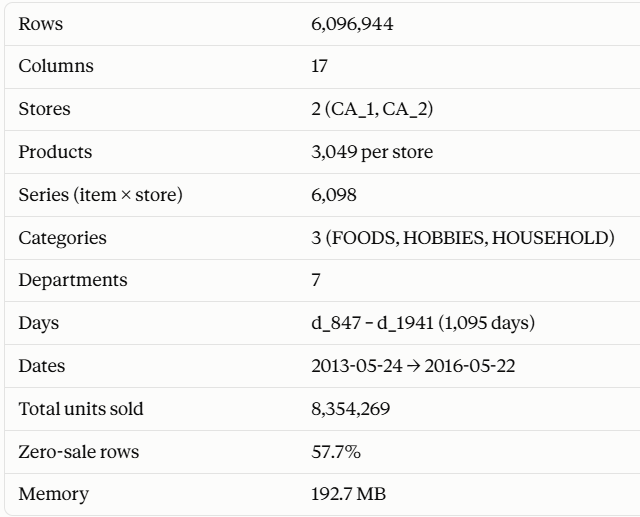